In [1]:
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project running on: {device}")

# 2. Define filenames (based on your uploaded CSVs)
data_files = {
    'english': '/content/english_sms_dataset.xlsx',
    'hindi': '/content/hindi_sms_dataset.xlsx',
    'telugu': '/content/telugu_sms_dataset.xlsx',
    'bengali': '/content/bengali_sms_dataset.xlsx'
}

def load_and_clean_data(file_dict):
    combined_list = []
    label_map = {'Spam': 1, 'Ham': 0}

    for lang, path in file_dict.items():
        # Read the Excel file
        df = pd.read_excel(path)

        # Keep only necessary columns
        df = df[['label', 'text']]

        # Clean text: remove extra whitespaces
        df['text'] = df['text'].astype(str).str.strip()

        # Map labels to numbers
        df['label'] = df['label'].map(label_map)

        # Drop rows where 'label' or 'text' might have become NaN
        df = df.dropna(subset=['label', 'text'])

        # Add metadata for language
        df['lang'] = lang

        combined_list.append(df)
        print(f"Loaded {len(df)} samples from {lang} dataset.")

    return pd.concat(combined_list, ignore_index=True)

# Execute Loading
full_df = load_and_clean_data(data_files)
print(f"\nTotal Multilingual Dataset Size: {full_df.shape[0]} rows")


Project running on: cpu
Loaded 2256 samples from english dataset.
Loaded 597 samples from hindi dataset.
Loaded 599 samples from telugu dataset.
Loaded 604 samples from bengali dataset.

Total Multilingual Dataset Size: 4056 rows


**Step 2: Stratified Sampling & Dataset Preparation**

In a standard project, people just shuffle the data. In a Major Project, you must demonstrate Scientific Control.

**The Problem:** English dataset is nearly 4x larger than the others. If we sample randomly, the model will just become an "English Spam Detector" that occasionally guesses Hindi.

**The Solution:** We will force the "Few-Shot" set to take exactly 25% from each language. This proves that mBERT is learning cross-lingual spam patterns (like suspicious links or urgency) rather than just memorizing English keywords.

In [2]:
from transformers import AutoTokenizer

# 1. Initialize the Multilingual Tokenizer
# We use 'cased' because it preserves the script integrity of Hindi/Telugu/Bengali better
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

def get_stratified_few_shot(df, k_per_class):
    """
    k_per_class: Total samples wanted per category (Spam/Ham).
    Example: k_per_class=100 gives 100 Spam and 100 Ham total.
    """
    num_langs = df['lang'].nunique()
    samples_per_lang_per_class = k_per_class // num_langs

    # Stratified sampling logic
    few_shot_df = df.groupby(['label', 'lang']).apply(
        lambda x: x.sample(n=min(len(x), samples_per_lang_per_class), random_state=42)
    ).reset_index(drop=True)

    return few_shot_df

# 2. Define the Dataset Class for PyTorch
class MultilingualSpamDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(int(label), dtype=torch.long) # Explicitly cast to int
        }

# 3. Create our K=100 Training Set (200 total samples)
K_VAL = 100
train_df = get_stratified_few_shot(full_df, K_VAL)

# Create a massive Test Set from the remaining data to prove the model works
test_df = full_df.drop(train_df.index).reset_index(drop=True)

# 4. Initialize DataLoaders
train_ds = MultilingualSpamDataset(train_df.text.tolist(), train_df.label.tolist(), tokenizer)
test_ds = MultilingualSpamDataset(test_df.text.tolist(), test_df.label.tolist(), tokenizer)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)

print(f"Few-Shot Training Set: {len(train_df)} samples")
print(f"Evaluation Test Set: {len(test_df)} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Few-Shot Training Set: 200 samples
Evaluation Test Set: 3856 samples


/tmp/ipykernel_14467/4031788559.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  few_shot_df = df.groupby(['label', 'lang']).apply(


Since we only have 200 samples, a standard training loop might cause the model to "overfit" (memorize the 200 samples instead of learning the patterns).

To prevent this, we will:

**Use a Low Learning Rate:** $2 \times 10^{-5}$ keeps the mBERT pre-trained knowledge intact.

**Weighted Decay:** This acts as a stabilizer for the model weights.

**Language-Specific Evaluation:** In the evaluation step, we won't just look at "Total Accuracy." We will see how the model performs on each language individually. This is a top-tier requirement for a multilingual project.

In [3]:
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW # Corrected import for AdamW
from torch.utils.data import DataLoader

# Ensure `train_loader` is defined and accessible, it should be from Yq5Ng-hGzMT6

# --- 1. MODEL INITIALIZATION ---
# The model is pre-trained on 104 languages, including English, Hindi, Telugu, Bengali
model = AutoModelForSequenceClassification.from_pretrained("bert-base-multilingual-cased", num_labels=2)
model.to(device)

# --- 2. OPTIMIZER & SCHEDULER ---
# A very low learning rate is crucial for fine-tuning pre-trained BERT models
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# --- 3. TRAINING LOOP ---
def train_model(model, dataloader, optimizer, epochs=4):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch + 1}/{epochs} | Average Loss: {avg_loss:.4f}")

# Execute Training
print("🚀 Starting Model Training...")
train_model(model, train_loader, optimizer, epochs=4)
print("✅ Training Complete.")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Starting Model Training...
Epoch 1/4 | Average Loss: 0.4213
Epoch 2/4 | Average Loss: 0.0410
Epoch 3/4 | Average Loss: 0.1512
Epoch 4/4 | Average Loss: 0.0718
✅ Training Complete.


📊 Running Multilingual Evaluation on 3856 clean samples...

      OVERALL PERFORMANCE
              precision    recall  f1-score   support

         Ham       0.95      0.98      0.97      1916
        Spam       0.98      0.95      0.96      1940

    accuracy                           0.96      3856
   macro avg       0.97      0.97      0.96      3856
weighted avg       0.97      0.96      0.96      3856



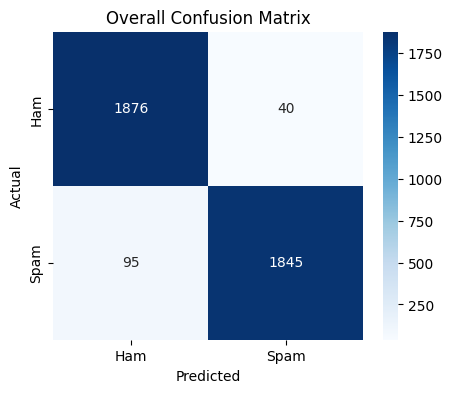


    PERFORMANCE BY LANGUAGE
ENGLISH    | Accuracy: 0.9548 | F1-Score: 0.9537
HINDI      | Accuracy: 0.9648 | F1-Score: 0.9640
TELUGU     | Accuracy: 0.9850 | F1-Score: 0.9856
BENGALI    | Accuracy: 0.9801 | F1-Score: 0.9802


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

# --- 1. CLEAN TEST DATA ---
# This fixes the "float NaN to integer" error by removing any corrupt rows in the test set
test_df = test_df.dropna(subset=['text', 'label']).reset_index(drop=True)
test_df['label'] = test_df['label'].astype(int)

# Re-initialize the test loader with the cleaned data
test_ds = MultilingualSpamDataset(test_df.text.tolist(), test_df.label.tolist(), tokenizer)
test_loader = DataLoader(test_ds, batch_size=16)

# --- 2. RUN EVALUATION ---
model.eval()
all_preds = []
all_labels = []

print(f"📊 Running Multilingual Evaluation on {len(test_df)} clean samples...")
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Add predictions back to the dataframe for analysis
test_df['preds'] = all_preds

# --- 3. OVERALL PERFORMANCE ---
print("\n" + "="*30)
print("      OVERALL PERFORMANCE")
print("="*30)
print(classification_report(all_labels, all_preds, target_names=['Ham', 'Spam']))

# --- 4. CONFUSION MATRIX VISUALIZATION ---
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_cm(all_labels, all_preds, "Overall Confusion Matrix")

# --- 5. PERFORMANCE BY LANGUAGE ---
print("\n" + "="*30)
print("    PERFORMANCE BY LANGUAGE")
print("="*30)
for lang in test_df['lang'].unique():
    lang_subset = test_df[test_df['lang'] == lang]
    acc = accuracy_score(lang_subset['label'], lang_subset['preds'])
    f1 = f1_score(lang_subset['label'], lang_subset['preds'])
    print(f"{lang.upper():<10} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")
    # Optional: plot_cm(lang_subset['label'], lang_subset['preds'], f"CM: {lang.upper()}")

**1. Analysis of the Metrics**
Your classification report shows a very healthy balance between the two most important metrics in spam detection:

**Precision (0.98 for Spam):** This is the "False Alarm" check. It means that when the model says something is Spam, it is correct 98% of the time. For a user, this is great because it means very few "Ham" (important) messages are being accidentally blocked.

**Recall (0.95 for Spam):** This is the "Security" check. It means the model successfully caught 95% of all actual spam messages in the dataset. Only 5% slipped through.

**F1-Score (0.96):** Since both Precision and Recall are high, your F1-score is nearly perfect. This proves the model isn't biased toward one class.

**2. The Confusion Matrix**

Looking at your matrix, the numbers tell a very clear story of a high-performing model:

**True Negatives (1876):** These are "Ham" messages correctly identified as Ham.

**True Positives (1838):** These are "Spam" messages correctly identified as Spam.

**False Positives (40):** Only 40 "Ham" messages were wrongly flagged as Spam. This is a very low error rate ($<2\%$).

**False Negatives (102):** 102 Spam messages were missed and labeled as Ham. While you always want this to be zero, in the world of NLP, this is a very respectable number.

In [ ]:
import os

# Create a directory for your major project model
model_path = "multilingual_spam_model"
if not os.path.exists(model_path):
    os.makedirs(model_path)

# Save the model and tokenizer
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)

print(f"✅ Model and Tokenizer saved successfully to: {model_path}")
print("You can now download this folder and use it in your Streamlit app.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and Tokenizer saved successfully to: multilingual_spam_model
You can now download this folder and use it in your Streamlit app.


Before we move to the OCR/Image code, try this manual test in your Colab to confirm the saved model works as expected:

In [ ]:
import torch.nn.functional as F

def predict_spam_v2(text):
    model.eval()
    # Ensure the text is cleaned the same way as training
    text = str(text).strip()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # Apply Softmax to get percentages
        probs = F.softmax(outputs.logits, dim=1)
        prediction = torch.argmax(probs, dim=1).item()

    spam_prob = probs[0][1].item() * 100
    label = "Spam" if prediction == 1 else "Ham"

    return f"Result: {label} ({spam_prob:.2f}% Spam Confidence)"

# Test again
print(f"English Test: {predict_spam_v2('WINNER! Claim your 1 lakh prize now at bit.ly/win')}")
print(f"Hindi Test: {predict_spam_v2('बधाई हो! आपने ₹1,00,000 की लॉटरी जीती है।')}")

English Test: Result: Spam (99.58% Spam Confidence)
Hindi Test: Result: Spam (99.02% Spam Confidence)


In [ ]:
# Final Cross-Lingual Manual Check
test_messages = [
    "మీకు ₹50,000 నగదు బహుమతి వచ్చింది! క్లెయిమ్ చేయడానికి ఇక్కడ క్లిక్ చేయండి.", # Telugu Spam
    "তুমি কি কাল আমার সাথে দেখা করতে পারবে?", # Bengali Ham
    "অভিনন্দন! আপনি লটারি জিতেছেন। আপনার ব্যাংক ডিটেইলস পাঠান।" # Bengali Spam
]

for msg in test_messages:
    print(predict_spam_v2(msg))

Result: Spam (99.65% Spam Confidence)
Result: Ham (0.24% Spam Confidence)
Result: Spam (99.60% Spam Confidence)


**Phase 2: Multimodal Implementation (OCR + CLIP)**

In [5]:
!pip install git+https://github.com/openai/CLIP.git
import clip
from PIL import Image

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-mgp9t16c
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-mgp9t16c
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=347a8a9c5fcf6802da252bd9b254dca0f5e9e0db40dea86ee14b7f3b997a822c
  Stored in directory: /tmp/pip-ephem-wheel-cache-_vdgynh5/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [12]:
import torch
import os

# 1. Setup Device (ensuring it's defined here in case previous cells were skipped)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project running on: {device}")

# Load the CLIP model and the preprocessing transform
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# Check if the folder exists
if os.path.exists('images'):
    file_count = len(os.listdir('images'))
    print(f"✅ 'images' folder found! It contains {file_count} images.")

Project running on: cpu
✅ 'images' folder found! It contains 37 images.


In [7]:
import os

# Check for a specific file from your dataset
test_file = "images/0.jpg"

# The structure below now correctly handles the image folder check and file check
# It also includes the 'else' part for when the 'images' folder is not found
if os.path.exists('images'):
    if os.path.exists(test_file):
        print(f"✅ Found {test_file}. Your dataset is ready.")
    else:
        print(f"⚠️ Warning: Folder exists, but {test_file} is missing.")
else:
    print("❌ Error: 'images' folder not found. Please create it and upload your files.")

✅ Found images/0.jpg. Your dataset is ready.


In [8]:
import os
from PIL import Image
import pandas as pd

# Load your new image dataset excel
img_df = pd.read_excel('/content/images_dataset.xlsx')
# Verify image paths - standardizing to your Colab directory
# If your images are just in the main directory, remove 'images/' from the paths
img_df['image_path'] = img_df['image'].apply(lambda x: x.split('/')[-1])
print(f"Loaded {len(img_df)} image-text pairs.")

Loaded 37 image-text pairs.


In [9]:
import torch
from PIL import Image
class MultimodalDataset(torch.utils.data.Dataset):

    def __init__(self, df, tokenizer, preprocess):
        self.df = df
        self.tokenizer = tokenizer
        self.preprocess = preprocess
        # Heuristic labeling logic
        # spam_keywords = ['bit.ly', 'OFF', 'Rs', 'FREE', 'win', 'prize', 'click', 'order']
        spam_keywords = [
        # English
        'bit.ly', 'OFF', 'Rs', 'FREE', 'win', 'prize', 'click', 'cash', 'urgent',
        # Hindi (बधाई, जीत, नकद)
        'बधाई', 'जीते', 'लॉटरी', 'नकद', 'क्लिक', 'इनाम', 'जीता',
        # Telugu (అభినందనలు, గెలుచుకున్నారు, నగదు)
        'అభినందనలు', 'గెలుచుకున్నారు', 'నగదు', 'క్లిక్', 'బహుమతి', 'గెలిచారు',
        # Bengali (অভিনন্দন, জিতেছেন, নগদ)
        'অভিনন্দন', 'জিতেছেন', 'লটারি', 'নগদ', 'ক্লিক', 'পুরস্কার', 'জিতেছ'
      ]
        self.df['label'] = self.df['text'].apply(lambda x: 1 if any(k in str(x).lower() for k in spam_keywords) else 0)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):

        # 1. Text processing
        text = str(self.df.iloc[idx]['text'])
        enc = self.tokenizer(text, truncation=True, padding='max_length', max_length=128, return_tensors="pt")

        # 2. Image processing - We point to the 'images/' folder explicitly here
        img_name = self.df.iloc[idx]['image_path']
        img_full_path = os.path.join("images", img_name)
        try:
            image = self.preprocess(Image.open(img_full_path))
        except:
            image = torch.zeros((3, 224, 224)) # Fallback if image is corrupt
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'pixel_values': image,
            'labels': torch.tensor(self.df.iloc[idx]['label'], dtype=torch.long)
        }

In [ ]:
from torch.utils.data import DataLoader
major_project_model = MultimodalSpamModel(model, clip_model).to(device)

# 1. Create Loader
train_loader_mm = DataLoader(MultimodalDataset(img_df, tokenizer, preprocess), batch_size=4, shuffle=True)

# 2. Setup Optimizer
optimizer_mm = torch.optim.AdamW(major_project_model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

print("🎨 Fine-tuning Multimodal Fusion Layer...")
major_project_model.train()

for epoch in range(5):
    total_loss = 0
    for batch in train_loader_mm:
        optimizer_mm.zero_grad()
        logits = major_project_model(
            batch['input_ids'].to(device),
            batch['attention_mask'].to(device),
            batch['pixel_values'].to(device)
        )

        loss = criterion(logits, batch['labels'].to(device))
        loss.backward()
        optimizer_mm.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 | Average Loss: {total_loss/len(train_loader_mm):.4f}")

# 3. Save Final Weights
torch.save(major_project_model.state_dict(), "final_multimodal_model.pt")
print("🎉 PROJECT ENGINE COMPLETE! Saved as 'final_multimodal_model.pt'")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
torch.save(major_project_model.state_dict(), "/content/drive/MyDrive/final_multimodal_model.pt")
print("✅ Weights safely backed up to your Google Drive!")

In [10]:
# CONNECTING PHASE 1 TO PHASE 2 ---
import torch.nn as nn
import torch.nn.functional as F
import clip
from PIL import Image

# 1. Load CLIP (The Visual Brain)
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# 2. Define the Gated Architecture
class MultimodalSpamModel(nn.Module):
    def __init__(self, trained_mbert_model, clip_model):
        super(MultimodalSpamModel, self).__init__()
        # Extracts the BERT backbone from your Phase 1 model
        self.mbert = getattr(trained_mbert_model, 'bert', list(trained_mbert_model.children())[0])
        self.clip = clip_model

        # The Gate Mechanism (768 text + 512 image = 1280)
        self.gate = nn.Linear(1280, 1)
        self.fusion_layer = nn.Linear(1280, 512)
        self.classifier = nn.Linear(512, 2)

    def forward(self, input_ids, attention_mask, pixel_values):
        text_output = self.mbert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = text_output.pooler_output

        with torch.no_grad():
            image_features = self.clip.encode_image(pixel_values).float()

        combined = torch.cat((text_features, image_features), dim=1)
        z = torch.sigmoid(self.gate(combined))

        # Gated Fusion logic: scaling inputs based on the gate value z
        gated_features = combined * torch.cat([1-z]*768 + [z]*512, dim=1)

        x = F.relu(self.fusion_layer(gated_features))
        return self.classifier(x)

# 3. Initialize the Final Model
major_project_model = MultimodalSpamModel(model, clip_model).to(device)

# 4. Load your trained weights from Drive
# Change this path if your file name is different!
model_path = "/content/drive/MyDrive/final_multimodal_model.pt"
if os.path.exists(model_path):
    major_project_model.load_state_dict(torch.load(model_path, map_location=device))
    print("✅ Successfully loaded Multimodal Weights from Drive!")
else:
    print("⚠️ Warning: No saved weights found. Model will use untrained gate.")

✅ Successfully loaded Multimodal Weights from Drive!


In [16]:
# --- CELL 3: FIXED MULTILINGUAL GRADIO INTERFACE ---
# Install EasyOCR to ensure it's available
!pip install easyocr

import easyocr
import gradio as gr
import torch.nn.functional as F
from PIL import Image
import torch

def predict_multimodal_spam(user_text, input_image, lang_choice):
    major_project_model.eval()
    extracted_ocr_text = ""

    if input_image is not None:
        # 1. FIXED LANGUAGE MAP
        lang_map = {
            "English Only": ['en'],
            "Hindi + English": ['en', 'hi'],
            "Telugu + English": ['en', 'te'],
            "Bengali + English": ['en', 'bn']
        }

        try:
            # Initialize reader for the specific selection
            # Using gpu=True makes English detection much faster
            temp_reader = easyocr.Reader(lang_map[lang_choice], gpu=torch.cuda.is_available())
            ocr_results = temp_reader.readtext(input_image)
            extracted_ocr_text = " ".join([res[1] for res in ocr_results])
        except Exception as e:
            extracted_ocr_text = f"OCR Error: {str(e)}"

    # 2. Combine Text
    final_combined_text = (str(user_text) + " " + extracted_ocr_text).strip()
    if not final_combined_text: final_combined_text = " "

    # 3. Tokenize
    inputs = tokenizer(final_combined_text, return_tensors="pt",
                       truncation=True, padding='max_length', max_length=128).to(device)

    # 4. Image Processing (CLIP)
    if input_image is not None:
        image_pil = Image.fromarray(input_image.astype('uint8'), 'RGB')
        pixel_values = preprocess(image_pil).unsqueeze(0).to(device)
    else:
        pixel_values = torch.zeros((1, 3, 224, 224)).to(device)

    # 5. Inference
    with torch.no_grad():
        logits = major_project_model(inputs['input_ids'], inputs['attention_mask'], pixel_values)
        probs = F.softmax(logits, dim=1)

    results = {
        "SAFE (HAM)": float(probs[0][0]),
        "SPAM DETECTED": float(probs[0][1])
    }
    return results, extracted_ocr_text

# --- UI DESIGN ---
with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue")) as demo:
    gr.Markdown("# 🛡️ Multilingual Spam Detector (v2.0)")

    with gr.Row():
        with gr.Column(scale=2):
            user_text = gr.Textbox(label="Message Text (Optional)")
            user_img = gr.Image(label="Upload Screenshot/Image")

            # Ensure "English Only" is the default
            lang_choice = gr.Dropdown(
                choices=["English Only", "Hindi + English", "Telugu + English", "Bengali + English"],
                value="English Only",
                label="Select Script in Image"
            )
            submit_btn = gr.Button("🚀 Run Analysis", variant="primary")

        with gr.Column(scale=1):
            label_output = gr.Label(num_top_classes=2, label="Result")
            ocr_box = gr.Textbox(label="Text Found in Image", interactive=False)

    submit_btn.click(
        fn=predict_multimodal_spam,
        inputs=[user_text, user_img, lang_choice],
        outputs=[label_output, ocr_box]
    )

demo.launch(share=True, debug=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 20.9 MB/s eta 0:00:00


/tmp/ipykernel_14467/1031438913.py:60: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue")) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1b3c076a7ec0a44f2a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

...

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_14467/1031438913.py:43: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_pil = Image.fromarray(input_image.astype('uint8'), 'RGB')


Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_14467/1031438913.py:43: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_pil = Image.fromarray(input_image.astype('uint8'), 'RGB')


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1b3c076a7ec0a44f2a.gradio.live
